In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
import pandas as pd

# Read only required columns with correct dtypes
movies = pd.read_csv(
    r"C:\Users\USRE\Downloads\movie\movie.csv",
    usecols=["movieId", "title"],
    dtype={
        "movieId": "int32",
        "title": "string"
    }
)

ratings = pd.read_csv(
    r"C:\Users\USRE\Downloads\movie\rating.csv",
    usecols=["userId", "movieId", "rating"],
    dtype={
        "userId": "int32",
        "movieId": "int32",
        "rating": "float32"
    },
    nrows=100000   # ⭐ THIS FIXES THE MEMORY ERROR
)

data = pd.merge(ratings, movies, on="movieId")

print(data.head())

   userId  movieId  rating                                              title
0       1        2     3.5                                     Jumanji (1995)
1       1       29     3.5  City of Lost Children, The (Cité des enfants p...
2       1       32     3.5          Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
3       1       47     3.5                        Seven (a.k.a. Se7en) (1995)
4       1       50     3.5                         Usual Suspects, The (1995)


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   userId   100000 non-null  int32  
 1   movieId  100000 non-null  int32  
 2   rating   100000 non-null  float32
 3   title    100000 non-null  string 
dtypes: float32(1), int32(2), string(1)
memory usage: 1.9 MB


In [24]:
top_movies = (
    data.groupby("title")
        .size()
        .sort_values(ascending=False)
        .head(10)
)
print(top_movies)

title
Pulp Fiction (1994)                          350
Forrest Gump (1994)                          340
Shawshank Redemption, The (1994)             305
Jurassic Park (1993)                         302
Silence of the Lambs, The (1991)             295
Star Wars: Episode IV - A New Hope (1977)    264
Braveheart (1995)                            262
Terminator 2: Judgment Day (1991)            256
Matrix, The (1999)                           253
Schindler's List (1993)                      247
dtype: int64


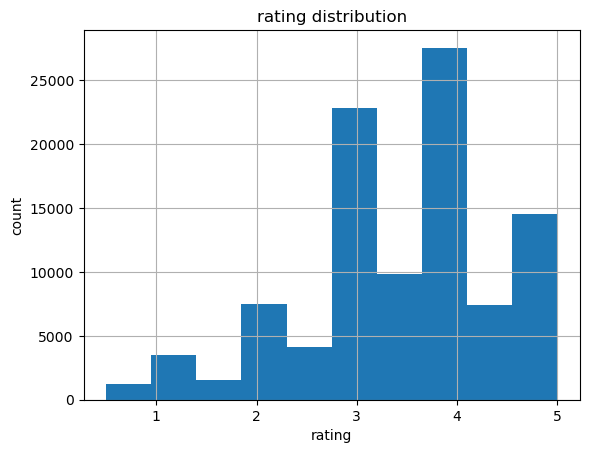

In [26]:
import matplotlib.pyplot as plt
data["rating"].hist(bins=10)
plt.xlabel("rating")
plt.ylabel("count")
plt.title("rating distribution")
plt.show()

In [34]:
movie_stats = data.groupby("title").agg(
    avg_rating=("rating", "mean"),
    rating_count=("rating", "count")
)
recommended = movie_stats[movie_stats["rating_count"] > 100].sort_values("avg_rating",ascending=False).head(10)
print(recommended)



                                                    avg_rating  rating_count
title                                                                       
Godfather: Part II, The (1974)                        4.419708           137
Shawshank Redemption, The (1994)                      4.413115           305
Godfather, The (1972)                                 4.395939           197
One Flew Over the Cuckoo's Nest (1975)                4.354730           148
Usual Suspects, The (1995)                            4.337054           224
Amelie (Fabuleux destin d'Amélie Poulain, Le) (...    4.273438           128
Fight Club (1999)                                     4.270531           207
Schindler's List (1993)                               4.263158           247
Casablanca (1942)                                     4.237705           122
Memento (2000)                                        4.214286           161


In [35]:
movie_matrix = data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
).fillna(0)

movie_matrix.head()

title,'Hellboy': The Seeds of Creation (2004),'Neath the Arizona Skies (1934),'Round Midnight (1986),'Til There Was You (1997),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),(Untitled) (2009),*batteries not included (1987),...And Justice for All (1979),...,Zookeeper (2011),Zoolander (2001),"Zorro, the Gay Blade (1981)",Zulu (1964),Zus & Zo (2001),"\\""Great Performances\""\"" Cats (1998)""",eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
from sklearn.metrics.pairwise import cosine_similarity

movie_similarity = cosine_similarity(movie_matrix)

movie_similarity.shape

(702, 702)

In [37]:
movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_matrix.index,
    columns=movie_matrix.index
)

movie_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,693,694,695,696,697,698,699,700,701,702
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.102916,0.261198,0.029091,0.139199,0.029488,0.112060,0.060641,0.062589,0.136902,...,0.103488,0.105296,0.067533,0.056789,0.060266,0.049544,0.120297,0.217311,0.039058,0.193935
2,0.102916,1.000000,0.180124,0.064014,0.140042,0.092464,0.160006,0.103785,0.000000,0.101933,...,0.025688,0.055422,0.028806,0.097192,0.046693,0.056763,0.066230,0.132186,0.063067,0.124745
3,0.261198,0.180124,1.000000,0.057323,0.156755,0.063552,0.207623,0.087128,0.053957,0.273834,...,0.079587,0.100744,0.030453,0.078874,0.139062,0.045888,0.219947,0.227909,0.027866,0.308486
4,0.029091,0.064014,0.057323,1.000000,0.300828,0.040654,0.073242,0.307392,0.042953,0.025546,...,0.112663,0.026456,0.048128,0.025982,0.033434,0.282404,0.052886,0.134173,0.033275,0.152802
5,0.139199,0.140042,0.156755,0.300828,1.000000,0.234223,0.169685,0.304162,0.000000,0.138848,...,0.096226,0.098120,0.053771,0.052956,0.038868,0.320732,0.107461,0.246207,0.082892,0.318524


In [42]:
def recommend_movies(movie_name):

    if movie_name not in movie_matrix.columns:
        print("Movie not found")
        return

    movie_ratings = movie_matrix[movie_name]

    similar_movies = movie_matrix.corrwith(movie_ratings)

    corr_df = pd.DataFrame(similar_movies, columns=['correlation'])
    corr_df.dropna(inplace=True)

    corr_df = corr_df.join(movie_stats['rating_count'])

    recommendations = corr_df[corr_df['rating_count'] > 100] \
                        .sort_values('correlation', ascending=False)

    print(recommendations.head(10))

In [43]:
recommend_movies("Toy Story (1995)")

                                                   correlation  rating_count
title                                                                       
Toy Story (1995)                                      1.000000           241
Toy Story 2 (1999)                                    0.420275           114
Willy Wonka & the Chocolate Factory (1971)            0.369307           139
Independence Day (a.k.a. ID4) (1996)                  0.361996           234
Mission: Impossible (1996)                            0.352920           178
Twister (1996)                                        0.335941           162
Finding Nemo (2003)                                   0.321467           107
Monsters, Inc. (2001)                                 0.312348           111
Star Wars: Episode VI - Return of the Jedi (1983)     0.310699           233
Rock, The (1996)                                      0.305588           140


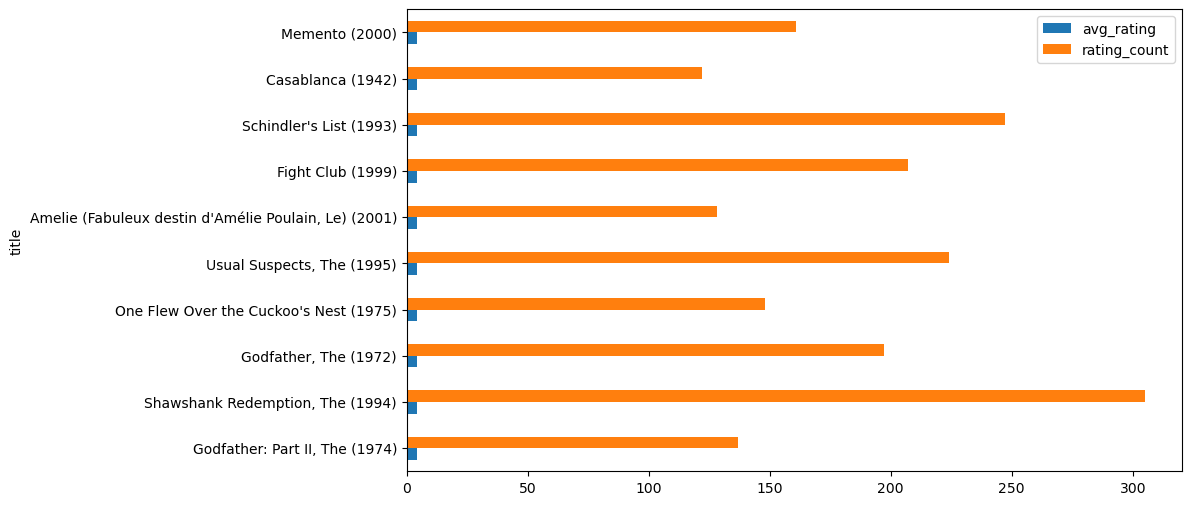

In [44]:
recommended.head(10).plot(kind='barh', figsize=(10,6))
plt.show()

In [45]:
movie_stats.sort_values('rating_count', ascending=False).head(10)

,avg_rating,rating_count
title,,
Pulp Fiction (1994),4.100000,350
Forrest Gump (1994),4.058824,340
"Shawshank Redemption, The (1994)",4.413115,305
Jurassic Park (1993),3.639073,302
"Silence of the Lambs, The (1991)",4.111865,295
Star Wars: Episode IV - A New Hope (1977),4.083333,264
Braveheart (1995),3.965649,262
Terminator 2: Judgment Day (1991),3.953125,256
"Matrix, The (1999)",4.063241,253
